In [1]:
import geopandas as gpd
import datetime
import json
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tx_fast_hydrology.muskingum import Muskingum, ModelCollection, Connection
from tx_fast_hydrology.simulation import AsyncSimulation

In [2]:
austin = gpd.read_file('../data/pruned_dissolved_streamstats/pruned_dissolved_streamstats.shp')
austin = austin.to_crs("EPSG:4326")
austin # SplitID is not unique but GridID [or HydroID] is 

,Shape_Leng,HydroID,From_Node,To_Node,NextDownID,PU_Order,geometry
0,105.639610,49134,1,2,71459,1,"LINESTRING (-98.15106 30.67753, -98.15103 30.6..."
1,366.551299,49135,3,4,73677,1,"LINESTRING (-98.15212 30.67471, -98.15208 30.6..."
2,304.279221,49136,5,6,67917,1,"LINESTRING (-98.13022 30.67405, -98.13022 30.6..."
3,502.404112,49137,7,8,75270,1,"LINESTRING (-98.15187 30.67358, -98.15187 30.6..."
4,413.433550,49138,9,10,79168,1,"LINESTRING (-98.14132 30.67359, -98.14129 30.6..."
...,...,...,...,...,...,...,...
38397,423.073160,87531,38355,23026,87355,444,"LINESTRING (-97.4835 30.20502, -97.4835 30.204..."
38398,573.161472,87532,38428,38212,87360,450,"LINESTRING (-97.47249 30.18312, -97.47246 30.1..."
38399,537.874242,87533,24343,24034,87534,467,"LINESTRING (-97.4249 30.18196, -97.42493 30.18..."
38400,370.102597,87534,24034,24062,87376,468,"LINESTRING (-97.4289 30.17869, -97.42893 30.17..."


In [3]:
austin['reach_ids'] = austin['HydroID'].astype('str')
austin['dx'] = austin['Shape_Leng']*0.3048
austin['K'] = austin['dx'] / 2.12
austin['X'] = [0.25 for i in range(austin['reach_ids'].size)]
austin['o_t'] = [0 for i in range(austin['reach_ids'].size)]
austin ['startnodes'] = [i for i in range(austin['reach_ids'].size)]

# $\Delta$T

In [4]:
print(f'Using the mean K, \u0394T must be less than {(2*austin['K'].values.mean()*(1-0.25)).item()} seconds')
print(f'Using the min K, \u0394T must be less than {(2*austin['K'].values.min()*(1-0.25)).item()} seconds')
print(f'Using the max K, \u0394T must be less than {(2*austin['K'].values.max()*(1-0.25)).item()} seconds')

Using the mean K, ΔT must be less than 88.12474190399477 seconds
Using the min K, ΔT must be less than 0.6469811320754717 seconds
Using the max K, ΔT must be less than 861.803887957302 seconds


In [5]:
austin

,Shape_Leng,HydroID,From_Node,To_Node,NextDownID,PU_Order,geometry,reach_ids,dx,K,X,o_t,startnodes
0,105.639610,49134,1,2,71459,1,"LINESTRING (-98.15106 30.67753, -98.15103 30.6...",49134,32.198953,15.188185,0.25,0,0
1,366.551299,49135,3,4,73677,1,"LINESTRING (-98.15212 30.67471, -98.15208 30.6...",49135,111.724836,52.700394,0.25,0,1
2,304.279221,49136,5,6,67917,1,"LINESTRING (-98.13022 30.67405, -98.13022 30.6...",49136,92.744306,43.747314,0.25,0,2
3,502.404112,49137,7,8,75270,1,"LINESTRING (-98.15187 30.67358, -98.15187 30.6...",49137,153.132773,72.232440,0.25,0,3
4,413.433550,49138,9,10,79168,1,"LINESTRING (-98.14132 30.67359, -98.14129 30.6...",49138,126.014546,59.440824,0.25,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38397,423.073160,87531,38355,23026,87355,444,"LINESTRING (-97.4835 30.20502, -97.4835 30.204...",87531,128.952699,60.826745,0.25,0,38397
38398,573.161472,87532,38428,38212,87360,450,"LINESTRING (-97.47249 30.18312, -97.47246 30.1...",87532,174.699617,82.405480,0.25,0,38398
38399,537.874242,87533,24343,24034,87534,467,"LINESTRING (-97.4249 30.18196, -97.42493 30.18...",87533,163.944069,77.332108,0.25,0,38399
38400,370.102597,87534,24034,24062,87376,468,"LINESTRING (-97.4289 30.17869, -97.42893 30.17...",87534,112.807272,53.210977,0.25,0,38400


In [6]:
endnodes = []
for i,v in enumerate(austin['NextDownID'].values):
    if v in austin['HydroID'].values:
        index = austin[austin['HydroID']== v].index[0]
        endnodes.append(austin ['startnodes'][index].item())
    else:
        endnodes.append(austin ['startnodes'][i].item())

In [7]:
austin['endnodes'] = endnodes

In [8]:
austin.columns

Index(['Shape_Leng', 'HydroID', 'From_Node', 'To_Node', 'NextDownID',
       'PU_Order', 'geometry', 'reach_ids', 'dx', 'K', 'X', 'o_t',
       'startnodes', 'endnodes'],
      dtype='object')

In [9]:
austin[['HydroID','NextDownID', 'startnodes', 'endnodes']]

,HydroID,NextDownID,startnodes,endnodes
0,49134,71459,0,22325
1,49135,73677,1,24543
2,49136,67917,2,18783
3,49137,75270,3,26136
4,49138,79168,4,30034
...,...,...,...,...
38397,87531,87355,38397,38221
38398,87532,87360,38398,38226
38399,87533,87534,38399,38400
38400,87534,87376,38400,38242


In [10]:
print(austin.crs)
austin['geometry']

EPSG:4326


0        LINESTRING (-98.15106 30.67753, -98.15103 30.6...
1        LINESTRING (-98.15212 30.67471, -98.15208 30.6...
2        LINESTRING (-98.13022 30.67405, -98.13022 30.6...
3        LINESTRING (-98.15187 30.67358, -98.15187 30.6...
4        LINESTRING (-98.14132 30.67359, -98.14129 30.6...
                               ...                        
38397    LINESTRING (-97.4835 30.20502, -97.4835 30.204...
38398    LINESTRING (-97.47249 30.18312, -97.47246 30.1...
38399    LINESTRING (-97.4249 30.18196, -97.42493 30.18...
38400    LINESTRING (-97.4289 30.17869, -97.42893 30.17...
38401    LINESTRING (-97.39856 30.18738, -97.39853 30.1...
Name: geometry, Length: 38402, dtype: geometry

In [11]:
paths = []

for line in austin['geometry']:
    coords = list(line.coords)  # Extract list of (x, y) tuples
    path = [[x, y] for x, y in coords]  # Convert to nested list
    paths.append([path])  # Match the structure: paths[i][0][j] = [x, y]

# Now wrap in a dict if you want to export to JSON
paths_json = {"paths": paths}


In [12]:
austin_dict = {
    'reach_ids': austin['reach_ids'].to_list(),
    'startnodes': austin['startnodes'].to_list(),
    'endnodes': austin['endnodes'].to_list(),
    'K': austin['K'].to_list(),
    'X': austin['X'].to_list(),
    'o_t': austin['o_t'].to_list(),
    'dx': austin['dx'].to_list(),
    'paths': paths,
}


In [13]:
austin_dict['datetime'] = '2024-12-31T23:58:00+00:00'
austin_dict['timedelta'] = 'P0DT0H1M0S'
austin_dict['name'] = "Austin"
austin_dict = {'model': austin_dict}
austin_dict['sinks'] = []
austin_dict['sources'] = []
austin_dict = {"Austin": austin_dict}
austin_dict = {'models': austin_dict}
austin_dict['connections'] = {}
austin_dict.keys()

dict_keys(['models', 'connections'])

In [14]:
with open('../data/austin_streamstats_densified.json', 'w') as f:
    json.dump(austin_dict, f, indent=2)

In [15]:
# Define model file input path
input_path = '../data/austin_streamstats_densified.json'
# Load model collection from file
model_collection = ModelCollection.from_file(input_path)

Text(0.5, 1.0, 'austin')

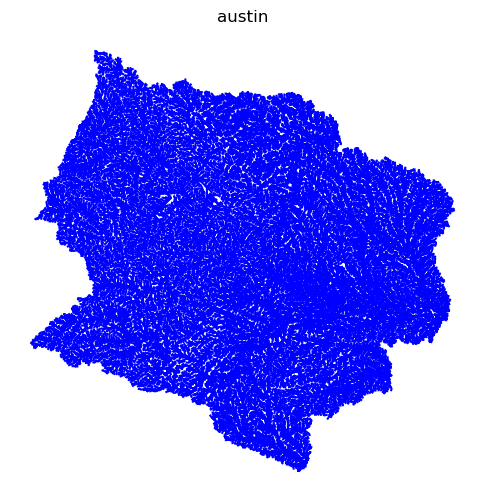

In [16]:
# Shoal creek and waller creek
fig, ax = plt.subplots(figsize=(6,6))
for model_name, model in model_collection.models.items():
    model.plot(ax=ax, c='b')
plt.axis('off')
plt.title('austin')

# 

# 